## Phase 2 – Step 1: Parse timestamps and compute daily totals per station

We load the raw counting data, parse the `DATUM` timestamp, derive a `DATE` column, and aggregate to daily totals for cyclists and pedestrians per `FK_STANDORT`.


In [1]:
import pandas as pd

df_raw = pd.read_csv("2025_verkehrszaehlungen_werte_fussgaenger_velo.csv")

df_raw["DATUM"] = pd.to_datetime(df_raw["DATUM"])

df_raw["DATE"] = df_raw["DATUM"].dt.date

df_raw.head()

,FK_STANDORT,DATUM,VELO_IN,VELO_OUT,FUSS_IN,FUSS_OUT,OST,NORD,DATE
0,4241,2025-01-01,3.0,0.0,NaN,NaN,2682297,1248328,2025-01-01
1,2989,2025-01-01,1.0,2.0,NaN,NaN,2682278,1248324,2025-01-01
2,2991,2025-01-01,18.0,2.0,NaN,NaN,2682756,1247323,2025-01-01
3,4255,2025-01-01,0.0,0.0,NaN,NaN,2682881,1246549,2025-01-01
4,4242,2025-01-01,1.0,0.0,NaN,NaN,2682337,1248451,2025-01-01


### Aggregate to daily totals and compute directional shares

For each station and day, we sum the IN/OUT counts and derive total daily volumes and relative shares for each direction and mode.

In [2]:
agg_cols = ["VELO_IN", "VELO_OUT", "FUSS_IN", "FUSS_OUT"]

df_daily = (
    df_raw
    .groupby(["FK_STANDORT", "DATE"], as_index=False)[agg_cols]
    .sum()
)

df_daily["VELO_DAY"] = df_daily["VELO_IN"] + df_daily["VELO_OUT"]
df_daily["FUSS_DAY"] = df_daily["FUSS_IN"] + df_daily["FUSS_OUT"]

df_daily["VELO_IN_SHARE"] = df_daily["VELO_IN"].div(df_daily["VELO_DAY"]).fillna(0.0)
df_daily["VELO_OUT_SHARE"] = df_daily["VELO_OUT"].div(df_daily["VELO_DAY"]).fillna(0.0)

df_daily["FUSS_IN_SHARE"] = df_daily["FUSS_IN"].div(df_daily["FUSS_DAY"]).fillna(0.0)
df_daily["FUSS_OUT_SHARE"] = df_daily["FUSS_OUT"].div(df_daily["FUSS_DAY"]).fillna(0.0)

df_daily.head()

,FK_STANDORT,DATE,VELO_IN,VELO_OUT,FUSS_IN,FUSS_OUT,VELO_DAY,FUSS_DAY,VELO_IN_SHARE,VELO_OUT_SHARE,FUSS_IN_SHARE,FUSS_OUT_SHARE
0,732,2025-01-01,66.0,237.0,0.0,0.0,303.0,0.0,0.217822,0.782178,0.0,0.0
1,732,2025-01-02,50.0,198.0,0.0,0.0,248.0,0.0,0.201613,0.798387,0.0,0.0
2,732,2025-01-03,112.0,386.0,0.0,0.0,498.0,0.0,0.224900,0.775100,0.0,0.0
3,732,2025-01-04,79.0,286.0,0.0,0.0,365.0,0.0,0.216438,0.783562,0.0,0.0
4,732,2025-01-05,62.0,239.0,0.0,0.0,301.0,0.0,0.205980,0.794020,0.0,0.0


## Phase 2 – Step 2: Reduce to one row per station (typical daily totals)

We aggregate `df_daily` to one record per `FK_STANDORT`, using the mean daily volumes and directional shares across all available days. Then we reattach the station coordinates.

In [3]:
df_daily["DATE"] = pd.to_datetime(df_daily["DATE"])

flow_cols = [
    "VELO_DAY", "FUSS_DAY",
    "VELO_IN", "VELO_OUT",
    "FUSS_IN", "FUSS_OUT",
    "VELO_IN_SHARE", "VELO_OUT_SHARE",
    "FUSS_IN_SHARE", "FUSS_OUT_SHARE",
]

df_station_daily = (
    df_daily
    .groupby("FK_STANDORT", as_index=False)[flow_cols]
    .mean()
)

df_station_daily.head()

,FK_STANDORT,VELO_DAY,FUSS_DAY,VELO_IN,VELO_OUT,FUSS_IN,FUSS_OUT,VELO_IN_SHARE,VELO_OUT_SHARE,FUSS_IN_SHARE,FUSS_OUT_SHARE
0,732,1289.053125,0.0,243.978125,1045.075000,0.0,0.0,0.189929,0.810071,0.0,0.0
1,1037,2703.446875,0.0,1871.521875,831.925000,0.0,0.0,0.689802,0.310198,0.0,0.0
2,2986,854.870130,0.0,439.285714,415.584416,0.0,0.0,0.500223,0.467310,0.0,0.0
3,2989,3664.640625,0.0,2566.918750,1097.721875,0.0,0.0,0.697724,0.302276,0.0,0.0
4,2991,1012.219828,0.0,721.426724,290.793103,0.0,0.0,0.719095,0.280905,0.0,0.0


### Attach station coordinates (OST / NORD)

We assume each `FK_STANDORT` has fixed coordinates and take the first occurrence from the raw data.

In [4]:
df_coords = (
    df_raw
    .groupby("FK_STANDORT", as_index=False)[["OST", "NORD"]]
    .first()
)

df_station_daily = df_station_daily.merge(df_coords, on="FK_STANDORT", how="left")

df_station_daily.head()


,FK_STANDORT,VELO_DAY,FUSS_DAY,VELO_IN,VELO_OUT,FUSS_IN,FUSS_OUT,VELO_IN_SHARE,VELO_OUT_SHARE,FUSS_IN_SHARE,FUSS_OUT_SHARE,OST,NORD
0,732,1289.053125,0.0,243.978125,1045.075000,0.0,0.0,0.189929,0.810071,0.0,0.0,2681319,1248665
1,1037,2703.446875,0.0,1871.521875,831.925000,0.0,0.0,0.689802,0.310198,0.0,0.0,2681339,1248647
2,2986,854.870130,0.0,439.285714,415.584416,0.0,0.0,0.500223,0.467310,0.0,0.0,2684578,1251966
3,2989,3664.640625,0.0,2566.918750,1097.721875,0.0,0.0,0.697724,0.302276,0.0,0.0,2682278,1248324
4,2991,1012.219828,0.0,721.426724,290.793103,0.0,0.0,0.719095,0.280905,0.0,0.0,2682756,1247323


## Phase 2 – Step 3: Create station GeoDataFrames for cyclists and pedestrians

We convert the station-level table into a GeoDataFrame using the Swiss coordinates (`OST`, `NORD`), set the CRS to LV95 (EPSG:2056), reproject to WGS84, and then create separate GeoDataFrames for bike and pedestrian stations.

In [5]:
import geopandas as gpd
from shapely.geometry import Point

gdf_stations = gpd.GeoDataFrame(
    df_station_daily.copy(),
    geometry=gpd.points_from_xy(df_station_daily["OST"], df_station_daily["NORD"]),
    crs="EPSG:2056"  # Swiss LV95
)

gdf_stations = gdf_stations.to_crs(epsg=4326)

gdf_stations.head()


,FK_STANDORT,VELO_DAY,FUSS_DAY,VELO_IN,VELO_OUT,FUSS_IN,FUSS_OUT,VELO_IN_SHARE,VELO_OUT_SHARE,FUSS_IN_SHARE,FUSS_OUT_SHARE,OST,NORD,geometry
0,732,1289.053125,0.0,243.978125,1045.075000,0.0,0.0,0.189929,0.810071,0.0,0.0,2681319,1248665,POINT (8.51555 47.3838)
1,1037,2703.446875,0.0,1871.521875,831.925000,0.0,0.0,0.689802,0.310198,0.0,0.0,2681339,1248647,POINT (8.51582 47.38363)
2,2986,854.870130,0.0,439.285714,415.584416,0.0,0.0,0.500223,0.467310,0.0,0.0,2684578,1251966,POINT (8.55933 47.41307)
3,2989,3664.640625,0.0,2566.918750,1097.721875,0.0,0.0,0.697724,0.302276,0.0,0.0,2682278,1248324,POINT (8.52819 47.38061)
4,2991,1012.219828,0.0,721.426724,290.793103,0.0,0.0,0.719095,0.280905,0.0,0.0,2682756,1247323,POINT (8.53433 47.37155)


### Split into bike and pedestrian station GeoDataFrames

We create separate GeoDataFrames for stations with non-zero typical daily bike counts and non-zero typical daily pedestrian counts.

In [6]:
# Stations with meaningful bike data
gdf_bike_stations = gdf_stations[gdf_stations["VELO_DAY"] > 0].copy()

# Stations with meaningful pedestrian data
gdf_ped_stations = gdf_stations[gdf_stations["FUSS_DAY"] > 0].copy()

print("Total stations:", len(gdf_stations))
print("Bike stations :", len(gdf_bike_stations))
print("Ped stations  :", len(gdf_ped_stations))

gdf_bike_stations.head()

Total stations: 28
Bike stations : 25
Ped stations  : 3


,FK_STANDORT,VELO_DAY,FUSS_DAY,VELO_IN,VELO_OUT,FUSS_IN,FUSS_OUT,VELO_IN_SHARE,VELO_OUT_SHARE,FUSS_IN_SHARE,FUSS_OUT_SHARE,OST,NORD,geometry
0,732,1289.053125,0.0,243.978125,1045.075000,0.0,0.0,0.189929,0.810071,0.0,0.0,2681319,1248665,POINT (8.51555 47.3838)
1,1037,2703.446875,0.0,1871.521875,831.925000,0.0,0.0,0.689802,0.310198,0.0,0.0,2681339,1248647,POINT (8.51582 47.38363)
2,2986,854.870130,0.0,439.285714,415.584416,0.0,0.0,0.500223,0.467310,0.0,0.0,2684578,1251966,POINT (8.55933 47.41307)
3,2989,3664.640625,0.0,2566.918750,1097.721875,0.0,0.0,0.697724,0.302276,0.0,0.0,2682278,1248324,POINT (8.52819 47.38061)
4,2991,1012.219828,0.0,721.426724,290.793103,0.0,0.0,0.719095,0.280905,0.0,0.0,2682756,1247323,POINT (8.53433 47.37155)


## Phase 3 – Step 4: Build cycling network for Zürich

We download a cycling network for the city of Zürich from OpenStreetMap using `osmnx`, enrich it with edge attributes (length, speed, bearing), and prepare a GeoDataFrame of edges with basic bike-friendliness flags.

In [7]:
import osmnx as ox

ox.settings.use_cache = True
ox.settings.log_console = False

place_name = "Zürich, Switzerland"

G_bike = ox.graph_from_place(
    place_name,
    network_type="bike",
    simplify=True
)

G_bike = ox.add_edge_speeds(G_bike)
G_bike = ox.add_edge_travel_times(G_bike)
G_bike = ox.add_edge_bearings(G_bike)

G_bike


### Prepare a bike edge GeoDataFrame and add bike-friendliness flags

We convert the graph edges to a GeoDataFrame and add simple flags such as `is_cycleway`, `is_quiet_street`, and a rough `bike_priority` score to use later in propagation heuristics.

In [8]:
import numpy as np

edges_bike_gdf = ox.graph_to_gdfs(G_bike, nodes=False, edges=True)

def highway_is_any(highway_value, target_types):
    if isinstance(highway_value, list):
        return any(h in target_types for h in highway_value)
    return highway_value in target_types

edges_bike_gdf["is_cycleway"] = edges_bike_gdf["highway"].apply(
    highway_is_any,
    target_types=["cycleway", "path"]
)

edges_bike_gdf["is_quiet_street"] = edges_bike_gdf["highway"].apply(
    highway_is_any,
    target_types=["residential", "living_street"]
)

edges_bike_gdf["is_main_road"] = edges_bike_gdf["highway"].apply(
    highway_is_any,
    target_types=["primary", "secondary", "tertiary"]
)

edges_bike_gdf["bike_priority"] = 1.0

edges_bike_gdf.loc[edges_bike_gdf["is_cycleway"], "bike_priority"] += 2.0
edges_bike_gdf.loc[edges_bike_gdf["is_quiet_street"], "bike_priority"] += 1.0
edges_bike_gdf.loc[edges_bike_gdf["is_main_road"], "bike_priority"] -= 0.5

edges_bike_gdf[["highway", "is_cycleway", "is_quiet_street", "is_main_road", "bike_priority"]].head()


highway  is_cycleway  is_quiet_street  is_main_road  \
u      v          key                                                         
453801 1990946417 0    tertiary        False            False          True   
       1229170106 0    tertiary        False            False          True   
453805 1990946417 0    tertiary        False            False          True   
       5132952919 0    tertiary        False            False          True   
       74574330   0    tertiary        False            False          True   

                       bike_priority  
u      v          key                 
453801 1990946417 0              0.5  
       1229170106 0              0.5  
453805 1990946417 0              0.5  
       5132952919 0              0.5  
       74574330   0              0.5

## Phase 3 – Step 5: Build pedestrian network for Zürich

We download a walking network for the city of Zürich from OpenStreetMap using `osmnx`, enrich it with edge attributes (length, speed, bearing), and prepare a GeoDataFrame of edges with basic pedestrian-comfort flags.

In [9]:
import osmnx as ox

G_ped = ox.graph_from_place(
    place_name,
    network_type="walk",
    simplify=True
)

G_ped = ox.add_edge_speeds(G_ped)
G_ped = ox.add_edge_travel_times(G_ped)
G_ped = ox.add_edge_bearings(G_ped)

G_ped


### Prepare a pedestrian edge GeoDataFrame and add comfort flags

We convert the graph edges to a GeoDataFrame and add simple flags such as `is_pedestrian_street`, `is_footway`, and a rough `ped_priority` score to use later in the pedestrian flow model.

In [10]:
import numpy as np

# Convert edges of the pedestrian graph to a GeoDataFrame (newer osmnx API)
edges_ped_gdf = ox.graph_to_gdfs(G_ped, nodes=False, edges=True)

def ped_highway_is_any(highway_value, target_types):
    if isinstance(highway_value, list):
        return any(h in target_types for h in highway_value)
    return highway_value in target_types

# Basic pedestrian-related flags
edges_ped_gdf["is_pedestrian_street"] = edges_ped_gdf["highway"].apply(
    ped_highway_is_any,
    target_types=["pedestrian", "living_street"]
)

edges_ped_gdf["is_footway"] = edges_ped_gdf["highway"].apply(
    ped_highway_is_any,
    target_types=["footway", "path", "steps"]
)

edges_ped_gdf["is_main_road"] = edges_ped_gdf["highway"].apply(
    ped_highway_is_any,
    target_types=["primary", "secondary", "tertiary"]
)

# Rough pedestrian comfort / priority score
edges_ped_gdf["ped_priority"] = 1.0  # base

edges_ped_gdf.loc[edges_ped_gdf["is_pedestrian_street"], "ped_priority"] += 2.0
edges_ped_gdf.loc[edges_ped_gdf["is_footway"], "ped_priority"] += 1.0
edges_ped_gdf.loc[edges_ped_gdf["is_main_road"], "ped_priority"] -= 0.5

# Quick sanity check
edges_ped_gdf[["highway", "is_pedestrian_street", "is_footway", "is_main_road", "ped_priority"]].head()


highway  is_pedestrian_street  is_footway  \
u      v           key                                                    
453818 9822191179  0    living_street                  True       False   
       301216590   0    living_street                  True       False   
       34404243    0    living_street                  True       False   
453828 11908195071 0      residential                 False       False   
       7605426322  0      residential                 False       False   

                        is_main_road  ped_priority  
u      v           key                              
453818 9822191179  0           False           3.0  
       301216590   0           False           3.0  
       34404243    0           False           3.0  
453828 11908195071 0           False           1.0  
       7605426322  0           False           1.0

## Phase 4 – Step 6: Snap bike stations to the cycling network and prepare bike seeds

We snap each bike counting station to its nearest cycling edge in the Zürich bike network and create a station–edge table with daily bike flows and directional shares. This will later be used as the seed set for the cyclist flow model.


In [23]:
import geopandas as gpd

gdf_bike_proj = gdf_bike_stations.to_crs(epsg=2056)
edges_bike_proj = edges_bike_gdf.to_crs(epsg=2056)

edges_bike_proj = edges_bike_proj.reset_index()  # brings 'u','v','key' out of the index

edges_bike_snap = edges_bike_proj[["u", "v", "key", "geometry"]].copy()

bike_station_edges = gpd.sjoin_nearest(
    gdf_bike_proj,
    edges_bike_snap,
    how="left",
    distance_col="snap_distance_m"
)

bike_station_edges = bike_station_edges.to_crs(epsg=4326)

bike_station_edges[[
    "FK_STANDORT",
    "VELO_DAY",
    "VELO_IN_SHARE",
    "VELO_OUT_SHARE",
    "u", "v", "key",
    "snap_distance_m"
]].head()

bike_seeds = bike_station_edges[[
    "FK_STANDORT",
    "VELO_DAY",
    "VELO_IN_SHARE",
    "VELO_OUT_SHARE",
    "u", "v", "key",
    "snap_distance_m",
    "geometry"
]].copy()


## Phase 4 – Step 7: Snap pedestrian stations to the walking network and prepare ped seeds

We snap each pedestrian counting station to its nearest walking edge in the Zürich pedestrian network and create a station–edge table with daily pedestrian flows and directional shares. This will be the seed set for the pedestrian flow model.

In [24]:
import geopandas as gpd

gdf_ped_proj = gdf_ped_stations.to_crs(epsg=2056)
edges_ped_proj = edges_ped_gdf.to_crs(epsg=2056)

edges_ped_proj = edges_ped_proj.reset_index()

edges_ped_snap = edges_ped_proj[["u", "v", "key", "geometry"]].copy()

ped_station_edges = gpd.sjoin_nearest(
    gdf_ped_proj,
    edges_ped_snap,
    how="left",
    distance_col="snap_distance_m"
)

ped_station_edges = ped_station_edges.to_crs(epsg=4326)

# Inspect the result
ped_station_edges[[
    "FK_STANDORT",
    "FUSS_DAY",
    "FUSS_IN_SHARE",
    "FUSS_OUT_SHARE",
    "u", "v", "key",
    "snap_distance_m"
]].head()

ped_seeds = ped_station_edges[[
    "FK_STANDORT",
    "FUSS_DAY",
    "FUSS_IN_SHARE",
    "FUSS_OUT_SHARE",
    "u", "v", "key",
    "snap_distance_m",
    "geometry"
]].copy()

### Define pedestrian seed records from snapped stations

For each pedestrian station, we now have a daily total (`FUSS_DAY`) and directional shares (`FUSS_IN_SHARE`, `FUSS_OUT_SHARE`) assigned to a specific edge `(u, v, key)`. This gives us the pedestrian seed table for the walking network.

In [19]:
ped_seeds = ped_station_edges[[
    "FK_STANDORT",
    "FUSS_DAY",
    "FUSS_IN_SHARE",
    "FUSS_OUT_SHARE",
    "u", "v", "key",
    "snap_distance_m",
    "geometry"
]].copy()

print("Min snap distance [m]:", ped_seeds["snap_distance_m"].min())
print("Max snap distance [m]:", ped_seeds["snap_distance_m"].max())

ped_seeds.head()


Min snap distance [m]: 0.15462282104655722
Max snap distance [m]: 2.985295961054513


,FK_STANDORT,FUSS_DAY,FUSS_IN_SHARE,FUSS_OUT_SHARE,u,v,key,snap_distance_m,geometry
9,3015,1725.887500,0.553001,0.446999,650460754,12810062814,0,2.576196,POINT (8.53728 47.34289)
9,3015,1725.887500,0.553001,0.446999,12810062814,650460754,0,2.576196,POINT (8.53728 47.34289)
10,3279,0.671875,0.278148,0.009352,2864633755,2864633767,0,0.154623,POINT (8.54333 47.37035)
13,4246,2359.239130,0.655616,0.344384,6167026070,11268771303,0,2.985296,POINT (8.52662 47.38861)
13,4246,2359.239130,0.655616,0.344384,11268771303,6167026070,0,2.985296,POINT (8.52662 47.38861)


## Phase 5 – Step 9: Define propagation parameters and helper functions

We define configurable parameters for the cyclist and pedestrian flow models (e.g. maximum propagation distance, minimum flow, decay strength) and a set of helper functions for distance-based decay and direction weighting using edge bearings.

In [20]:
import numpy as np

BIKE_MODEL_PARAMS = {
    "max_distance_m": 3000.0,
    "min_flow": 5.0,
    "decay_alpha": 0.0015,
    "max_bearing_diff": 90.0,
    "bearing_weight_exp": 2.0,
}

PED_MODEL_PARAMS = {
    "max_distance_m": 800.0,
    "min_flow": 3.0,
    "decay_alpha": 0.003,
    "max_bearing_diff": 120.0,
    "bearing_weight_exp": 1.0,
}


### Helper functions: bearing difference, direction weighting, and distance decay

We add small utilities to compute angular differences between edges, convert that into a direction weight, and apply a simple exponential distance decay to flows.

In [21]:
def bearing_diff_deg(b1, b2):
    """
    Smallest absolute difference between two bearings in degrees (0–180).
    """
    if b1 is None or b2 is None:
        return np.nan
    # Normalize to [0, 360)
    d = abs((b1 - b2 + 180) % 360 - 180)
    return d


def direction_weight(seed_bearing, edge_bearing, max_diff, exponent):
    """
    Compute a direction weight in [0, 1] for an edge given a seed bearing.

    - If bearings are identical -> weight near 1.
    - If difference >= max_diff -> weight = 0.
    - Otherwise: weight decays smoothly with angular difference.
    """
    d = bearing_diff_deg(seed_bearing, edge_bearing)
    if np.isnan(d) or d >= max_diff:
        return 0.0

    # Linear base weight in [0, 1], then sharpen with exponent
    base = 1.0 - (d / max_diff)
    return float(base ** exponent)


def distance_decay(flow_value, distance_m, alpha):
    """
    Apply an exponential distance decay to a flow value.

    flow(distance) = flow0 * exp(-alpha * distance_m)
    """
    if distance_m <= 0:
        return float(flow_value)
    return float(flow_value * np.exp(-alpha * distance_m))


## Phase 5 – Step 10: Propagate cyclist flows through the bike network

We use the bike seeds on specific edges as starting points and walk over the cycling network, splitting and decaying flows at each junction based on direction consistency and bike-friendliness of edges. The result is an aggregated daily cyclist flow per edge.


In [25]:
from collections import defaultdict
import pandas as pd

def highway_is_any(highway_value, target_types):
    """
    Utility to test if an OSM 'highway' tag (string or list) matches any of the given types.
    """
    if isinstance(highway_value, list):
        return any(h in target_types for h in highway_value)
    return highway_value in target_types


def propagate_bike_flows(G, seeds_gdf, params):
    """
    Propagate daily cyclist flows from seed edges through the bike network.

    Parameters
    ----------
    G : networkx.MultiDiGraph
        Cycling network graph.
    seeds_gdf : GeoDataFrame
        Bike seeds with columns: FK_STANDORT, VELO_DAY, VELO_IN_SHARE, VELO_OUT_SHARE, u, v, key.
    params : dict
        BIKE_MODEL_PARAMS-like dict.

    Returns
    -------
    edge_flow : dict
        {(u, v, key): total_flow} aggregated over all seeds.
    """
    max_distance_m   = params["max_distance_m"]
    min_flow         = params["min_flow"]
    decay_alpha      = params["decay_alpha"]
    max_bearing_diff = params["max_bearing_diff"]
    bearing_exp      = params["bearing_weight_exp"]

    edge_flow = defaultdict(float)

    for _, seed in seeds_gdf.iterrows():
        base_flow = float(seed["VELO_DAY"])
        if base_flow <= 0:
            continue

        u0 = seed["u"]
        v0 = seed["v"]
        k0 = seed["key"]

        # Safety check: seed edge must exist in the graph
        if not G.has_edge(u0, v0, k0):
            continue

        edge_data = G[u0][v0][k0]
        bearing_fwd = edge_data.get("bearing", None)

        # Forward and backward flow from this station (IN vs OUT)
        flow_fwd = base_flow * float(seed["VELO_IN_SHARE"])
        flow_back = base_flow * float(seed["VELO_OUT_SHARE"])

        # Helper: propagate from a given starting edge and seed bearing
        def propagate_from_edge(u_start, v_start, key_start, initial_flow, seed_bearing):
            if initial_flow <= 0:
                return

            # stack entries: (u, v, key, distance_from_seed, flow_here)
            stack = [(u_start, v_start, key_start, 0.0, float(initial_flow))]

            while stack:
                u, v, k, dist, flow_here = stack.pop()

                # Accumulate flow on this edge
                edge_flow[(u, v, k)] += flow_here

                # Stopping conditions
                if dist >= max_distance_m or flow_here < min_flow:
                    continue

                # Look at outgoing edges from node v
                out_edges = list(G.out_edges(v, keys=True, data=True))
                if not out_edges:
                    continue

                # First pass: compute weights for each outgoing edge
                weights = []
                meta = []
                for _, w, k2, data2 in out_edges:
                    length = float(data2.get("length", 0.0) or 0.0)
                    if length <= 0:
                        continue

                    new_dist = dist + length
                    if new_dist > max_distance_m:
                        continue

                    edge_bearing = data2.get("bearing", None)

                    # Direction weighting: if no bearings, treat as neutral (1.0)
                    if seed_bearing is None or edge_bearing is None:
                        dir_w = 1.0
                    else:
                        dir_w = direction_weight(
                            seed_bearing,
                            edge_bearing,
                            max_bearing_diff,
                            bearing_exp,
                        )

                    # Bike comfort weighting using OSM highway type
                    highway = data2.get("highway")
                    comfort = 1.0
                    if highway_is_any(highway, ["cycleway", "path"]):
                        comfort += 2.0
                    if highway_is_any(highway, ["residential", "living_street"]):
                        comfort += 1.0
                    if highway_is_any(highway, ["primary", "secondary", "tertiary"]):
                        comfort -= 0.5

                    weight = max(dir_w * comfort, 0.0)

                    if weight <= 0:
                        continue

                    weights.append(weight)
                    meta.append((v, w, k2, length, new_dist))

                if not weights:
                    continue

                sum_w = sum(weights)
                if sum_w <= 0:
                    continue

                # Second pass: distribute flow according to normalized weights
                for (v_curr, w_curr, k_curr, length, new_dist), w in zip(meta, weights):
                    share = w / sum_w
                    flow_candidate = flow_here * share

                    # Apply distance decay along this edge
                    flow_next = distance_decay(flow_candidate, length, decay_alpha)
                    if flow_next < min_flow:
                        continue

                    stack.append((v_curr, w_curr, k_curr, new_dist, flow_next))

        # Propagate forward (we arbitrarily map VELO_IN to u->v)
        if flow_fwd > 0:
            propagate_from_edge(u0, v0, k0, flow_fwd, bearing_fwd)

        # Propagate backward (map VELO_OUT to v->u if that edge exists)
        if flow_back > 0 and G.has_edge(v0, u0):
            # take the first available edge key for v->u
            key_back = list(G[v0][u0].keys())[0]
            edge_data_back = G[v0][u0][key_back]
            bearing_back = edge_data_back.get("bearing", None)
            propagate_from_edge(v0, u0, key_back, flow_back, bearing_back)

    return edge_flow


# Run the propagation for cyclists
bike_edge_flows = propagate_bike_flows(G_bike, bike_seeds, BIKE_MODEL_PARAMS)

# Convert dict to a DataFrame for inspection
df_bike_flows = pd.DataFrame(
    [
        {"u": u, "v": v, "key": k, "bike_flow_daily": flow}
        for (u, v, k), flow in bike_edge_flows.items()
    ]
)

df_bike_flows.head()

,u,v,key,bike_flow_daily
0,5130598288,26114451,0,244.828983
1,26114451,26114443,0,179.102841
2,26114443,5774850639,0,63.819597
3,5774850639,10594555678,0,60.731341
4,26114443,5774852998,0,112.006028


## Phase 5 – Step 11: Propagate pedestrian flows through the walking network

We use the pedestrian seeds on specific edges as starting points and walk over the pedestrian network, splitting and decaying flows at each junction. Compared to cyclists, pedestrians:
- walk shorter distances,
- care less about strict directionality,
- prefer pedestrian streets and footways more strongly.
The result is an aggregated daily pedestrian flow per edge.


In [26]:
from collections import defaultdict
import pandas as pd

def propagate_ped_flows(G, seeds_gdf, params):
    """
    Propagate daily pedestrian flows from seed edges through the pedestrian network.

    Parameters
    ----------
    G : networkx.MultiDiGraph
        Pedestrian network graph.
    seeds_gdf : GeoDataFrame
        Ped seeds with columns: FK_STANDORT, FUSS_DAY, FUSS_IN_SHARE, FUSS_OUT_SHARE, u, v, key.
    params : dict
        PED_MODEL_PARAMS-like dict.

    Returns
    -------
    edge_flow : dict
        {(u, v, key): total_flow} aggregated over all seeds.
    """
    max_distance_m   = params["max_distance_m"]
    min_flow         = params["min_flow"]
    decay_alpha      = params["decay_alpha"]
    max_bearing_diff = params["max_bearing_diff"]
    bearing_exp      = params["bearing_weight_exp"]

    edge_flow = defaultdict(float)

    for _, seed in seeds_gdf.iterrows():
        base_flow = float(seed["FUSS_DAY"])
        if base_flow <= 0:
            continue

        u0 = seed["u"]
        v0 = seed["v"]
        k0 = seed["key"]

        # Safety check: seed edge must exist in the graph
        if not G.has_edge(u0, v0, k0):
            continue

        edge_data = G[u0][v0][k0]
        bearing_fwd = edge_data.get("bearing", None)

        # Forward and backward flow from this station (IN vs OUT)
        flow_fwd = base_flow * float(seed["FUSS_IN_SHARE"])
        flow_back = base_flow * float(seed["FUSS_OUT_SHARE"])

        def propagate_from_edge(u_start, v_start, key_start, initial_flow, seed_bearing):
            if initial_flow <= 0:
                return

            # stack entries: (u, v, key, distance_from_seed, flow_here)
            stack = [(u_start, v_start, key_start, 0.0, float(initial_flow))]

            while stack:
                u, v, k, dist, flow_here = stack.pop()

                # Accumulate flow on this edge
                edge_flow[(u, v, k)] += flow_here

                # Stopping conditions
                if dist >= max_distance_m or flow_here < min_flow:
                    continue

                # Look at outgoing edges from node v
                out_edges = list(G.out_edges(v, keys=True, data=True))
                if not out_edges:
                    continue

                weights = []
                meta = []

                for _, w, k2, data2 in out_edges:
                    length = float(data2.get("length", 0.0) or 0.0)
                    if length <= 0:
                        continue

                    new_dist = dist + length
                    if new_dist > max_distance_m:
                        continue

                    edge_bearing = data2.get("bearing", None)

                    # Direction weighting: pedestrians care less about strict direction
                    if seed_bearing is None or edge_bearing is None:
                        dir_w = 1.0
                    else:
                        dir_w = direction_weight(
                            seed_bearing,
                            edge_bearing,
                            max_bearing_diff,
                            bearing_exp,
                        )

                    # Pedestrian comfort weighting
                    highway = data2.get("highway")
                    comfort = 1.0
                    if highway_is_any(highway, ["pedestrian", "living_street"]):
                        comfort += 2.0
                    if highway_is_any(highway, ["footway", "path", "steps"]):
                        comfort += 1.0
                    if highway_is_any(highway, ["primary", "secondary", "tertiary"]):
                        comfort -= 0.5

                    weight = max(dir_w * comfort, 0.0)
                    if weight <= 0:
                        continue

                    weights.append(weight)
                    meta.append((v, w, k2, length, new_dist))

                if not weights:
                    continue

                sum_w = sum(weights)
                if sum_w <= 0:
                    continue

                # Distribute flow according to normalized weights
                for (v_curr, w_curr, k_curr, length, new_dist), w in zip(meta, weights):
                    share = w / sum_w
                    flow_candidate = flow_here * share

                    # Apply distance decay along this edge
                    flow_next = distance_decay(flow_candidate, length, decay_alpha)
                    if flow_next < min_flow:
                        continue

                    stack.append((v_curr, w_curr, k_curr, new_dist, flow_next))

        # Propagate forward
        if flow_fwd > 0:
            propagate_from_edge(u0, v0, k0, flow_fwd, bearing_fwd)

        # Propagate backward if opposite direction edge exists
        if flow_back > 0 and G.has_edge(v0, u0):
            key_back = list(G[v0][u0].keys())[0]
            edge_data_back = G[v0][u0][key_back]
            bearing_back = edge_data_back.get("bearing", None)
            propagate_from_edge(v0, u0, key_back, flow_back, bearing_back)

    return edge_flow


# Run the propagation for pedestrians
ped_edge_flows = propagate_ped_flows(G_ped, ped_seeds, PED_MODEL_PARAMS)

# Convert dict to a DataFrame for inspection
df_ped_flows = pd.DataFrame(
    [
        {"u": u, "v": v, "key": k, "ped_flow_daily": flow}
        for (u, v, k), flow in ped_edge_flows.items()
    ]
)

df_ped_flows.head()


,u,v,key,ped_flow_daily
0,650460754,12810062814,0,1725.887500
1,12810062814,372762277,0,707.575992
2,372762277,5254058481,0,85.668834
3,5254058481,372762277,0,8.153128
4,5254058481,5254058482,0,81.549048


## Phase 6 – Step 12: Attach cyclist flows to bike edges

We join the modelled daily cyclist flows (`df_bike_flows`) back onto the OSM bike edges (`edges_bike_gdf`) using the edge identifiers `(u, v, key)`, fill missing flows with zero, and create a normalized flow column for visualization.


In [27]:
import geopandas as gpd

edges_bike_with_index = edges_bike_gdf.reset_index()

edges_bike_with_flow = edges_bike_with_index.merge(
    df_bike_flows,
    on=["u", "v", "key"],
    how="left",
)

edges_bike_with_flow["bike_flow_daily"] = edges_bike_with_flow["bike_flow_daily"].fillna(0.0)

max_bike_flow = edges_bike_with_flow["bike_flow_daily"].max()
if max_bike_flow > 0:
    edges_bike_with_flow["bike_flow_norm"] = edges_bike_with_flow["bike_flow_daily"] / max_bike_flow
else:
    edges_bike_with_flow["bike_flow_norm"] = 0.0

edges_bike_with_flow = gpd.GeoDataFrame(edges_bike_with_flow, geometry="geometry", crs=edges_bike_gdf.crs)

edges_bike_with_flow[["u", "v", "key", "highway", "bike_flow_daily", "bike_flow_norm"]].head()


,u,v,key,highway,bike_flow_daily,bike_flow_norm
0,453801,1990946417,0,tertiary,0.0,0.0
1,453801,1229170106,0,tertiary,0.0,0.0
2,453805,1990946417,0,tertiary,0.0,0.0
3,453805,5132952919,0,tertiary,0.0,0.0
4,453805,74574330,0,tertiary,0.0,0.0


### Attach pedestrian flows to pedestrian edges

We repeat the same procedure for the pedestrian network, joining `df_ped_flows` back onto `edges_ped_gdf` and creating a normalized pedestrian flow column.


In [28]:
edges_ped_with_index = edges_ped_gdf.reset_index()

edges_ped_with_flow = edges_ped_with_index.merge(
    df_ped_flows,
    on=["u", "v", "key"],
    how="left",
)

edges_ped_with_flow["ped_flow_daily"] = edges_ped_with_flow["ped_flow_daily"].fillna(0.0)

max_ped_flow = edges_ped_with_flow["ped_flow_daily"].max()
if max_ped_flow > 0:
    edges_ped_with_flow["ped_flow_norm"] = edges_ped_with_flow["ped_flow_daily"] / max_ped_flow
else:
    edges_ped_with_flow["ped_flow_norm"] = 0.0

edges_ped_with_flow = gpd.GeoDataFrame(edges_ped_with_flow, geometry="geometry", crs=edges_ped_gdf.crs)

edges_ped_with_flow[["u", "v", "key", "highway", "ped_flow_daily", "ped_flow_norm"]].head()


,u,v,key,highway,ped_flow_daily,ped_flow_norm
0,453818,9822191179,0,living_street,0.0,0.0
1,453818,301216590,0,living_street,0.0,0.0
2,453818,34404243,0,living_street,0.0,0.0
3,453828,11908195071,0,residential,0.0,0.0
4,453828,7605426322,0,residential,0.0,0.0


### Quick sanity checks for bike and pedestrian edge flows

We inspect how many edges have non-zero flow and the range of modelled values, to confirm that our propagation filled at least some edges.


In [29]:
# --- Cyclists ---
print("BIKES")
print("Total bike edges:", len(edges_bike_with_flow))
print("Edges with bike_flow_daily > 0:",
      (edges_bike_with_flow["bike_flow_daily"] > 0).sum())
print(edges_bike_with_flow["bike_flow_daily"].describe())

# Show top 5 edges by bike_flow_daily
edges_bike_with_flow.sort_values("bike_flow_daily", ascending=False)[
    ["u", "v", "key", "highway", "bike_flow_daily", "bike_flow_norm"]
].head(10)


BIKES
Total bike edges: 44611
Edges with bike_flow_daily > 0: 1103
count    44611.000000
mean         8.810605
std        134.963867
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       5848.295162
Name: bike_flow_daily, dtype: float64


,u,v,key,highway,bike_flow_daily,bike_flow_norm
1348,28137451,10240361846,0,tertiary,5848.295162,1.000000
36721,10240361846,28137447,0,tertiary,5342.959626,0.913593
1336,28137447,30826051,0,residential,5100.941226,0.872210
28984,5117664258,7668541311,0,cycleway,5096.664712,0.871479
43495,12856209146,9032014438,0,cycleway,4824.423363,0.824928
1971,30825896,28137451,0,tertiary,4786.461380,0.818437
1350,28137451,30825896,0,tertiary,4786.461380,0.818437
2006,30826051,28581686,0,residential,4775.894498,0.816630
1390,28581686,11583966683,0,residential,4669.951503,0.798515
39561,11583966683,52726923,0,residential,4565.376049,0.780634


In [30]:
# --- Pedestrians ---
print("\nPEDESTRIANS")
print("Total ped edges:", len(edges_ped_with_flow))
print("Edges with ped_flow_daily > 0:",
      (edges_ped_with_flow["ped_flow_daily"] > 0).sum())
print(edges_ped_with_flow["ped_flow_daily"].describe())

# Show top 5 edges by ped_flow_daily
edges_ped_with_flow.sort_values("ped_flow_daily", ascending=False)[
    ["u", "v", "key", "highway", "ped_flow_daily", "ped_flow_norm"]
].head(10)



PEDESTRIANS
Total ped edges: 164750
Edges with ped_flow_daily > 0: 253
count    164750.000000
mean          0.219318
std          14.808019
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        2359.239130
Name: ped_flow_daily, dtype: float64


,u,v,key,highway,ped_flow_daily,ped_flow_norm
137460,11268771303,6167026070,0,service,2359.239130,1.000000
80204,6167026070,11268771303,0,service,2359.239130,1.000000
80203,6167026070,3813176755,0,service,2167.598768,0.918770
16403,650460754,12810062814,0,footway,1725.887500,0.731544
154431,12810062814,650460754,0,footway,1725.887500,0.731544
16401,650460754,650460757,0,footway,1393.448337,0.590635
43374,3813176755,6165336402,0,footway,1262.559005,0.535155
137458,11268771303,11268771304,0,service,1215.070907,0.515027
16406,650460757,103120335,0,service,1153.494354,0.488926
137459,11268771303,6165336429,0,footway,1062.334604,0.450287


## Phase 6 – Step 13: Static map of cyclist flows in Zürich

We visualize the modelled daily cyclist flows on the bike network, highlighting edges with non-zero flow and overlaying the bike counting stations.


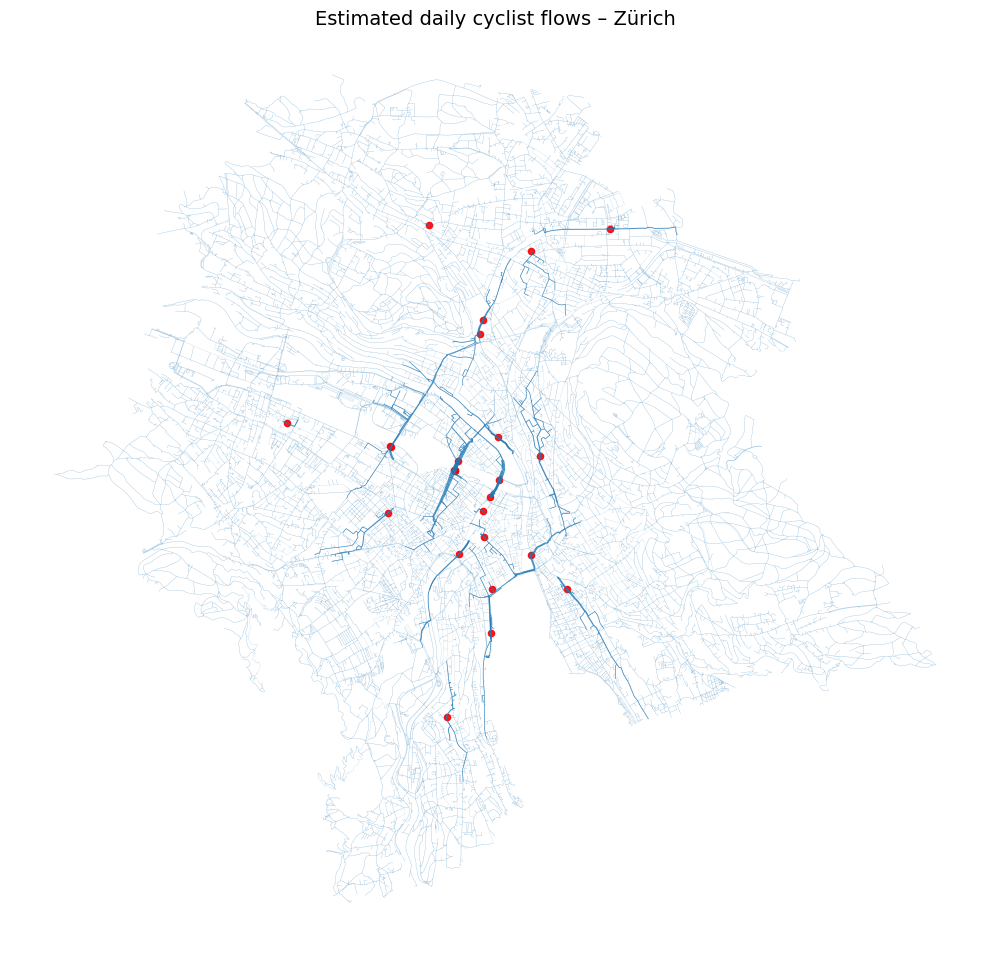

In [31]:
import matplotlib.pyplot as plt

# Reproject to Web Mercator for plotting
edges_bike_plot = edges_bike_with_flow.to_crs(epsg=3857)
bike_stations_plot = gdf_bike_stations.to_crs(epsg=3857)

# Keep only edges with non-zero flow
bike_edges_nonzero = edges_bike_plot[edges_bike_plot["bike_flow_daily"] > 0].copy()

# Line width scaled by normalized flow (avoid everything looking the same)
bike_edges_nonzero["lw"] = 0.5 + 3.0 * bike_edges_nonzero["bike_flow_norm"]

fig, ax = plt.subplots(figsize=(10, 10))

# Plot low-flow (zero) edges in light gray as context
edges_bike_plot[edges_bike_plot["bike_flow_daily"] == 0].plot(
    ax=ax,
    linewidth=0.2,
    alpha=0.3,
)

# Plot edges with flow
bike_edges_nonzero.plot(
    ax=ax,
    linewidth=bike_edges_nonzero["lw"],
    alpha=0.8,
)

# Overlay bike stations
bike_stations_plot.plot(
    ax=ax,
    markersize=20,
    color="red",
    alpha=0.9,
)

ax.set_axis_off()
ax.set_title("Estimated daily cyclist flows – Zürich", fontsize=14)
plt.tight_layout()
plt.show()

### Static map of pedestrian flows in Zürich

We repeat the visualization for the pedestrian network, showing modelled daily pedestrian flows and the pedestrian counting stations.

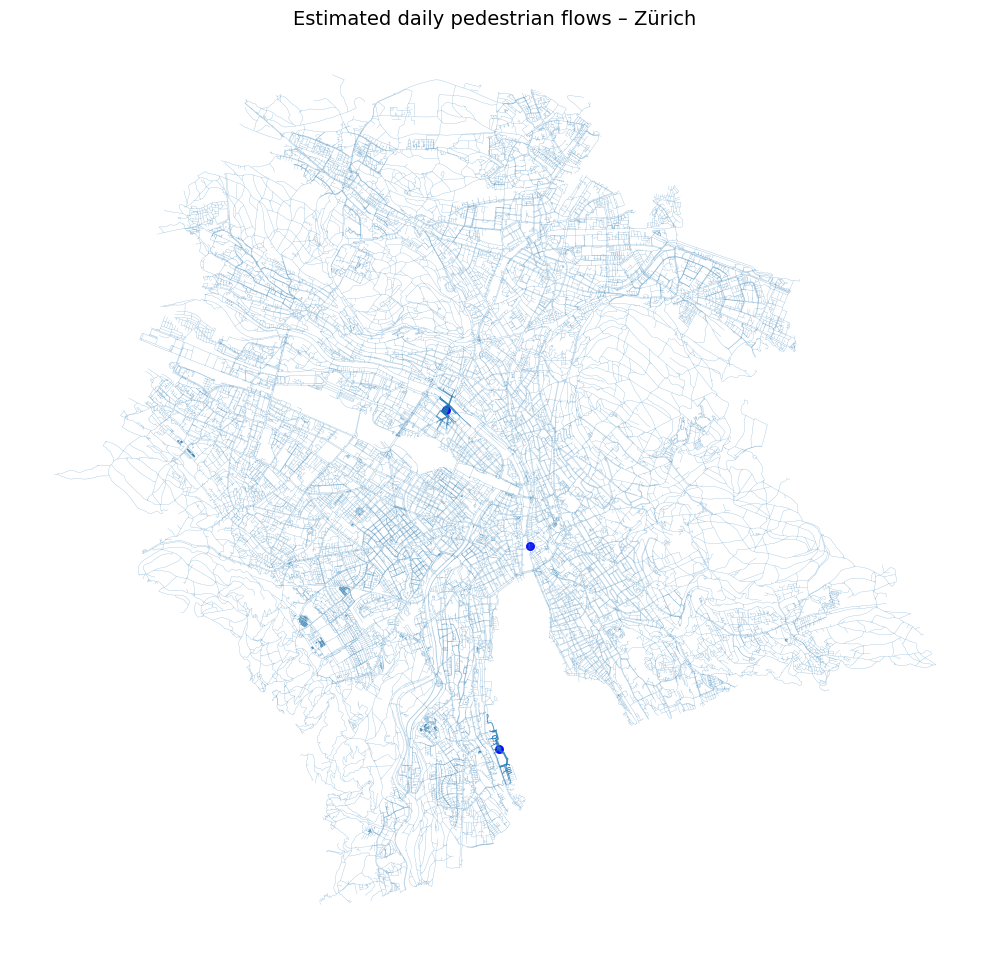

In [32]:
# Reproject to Web Mercator for plotting
edges_ped_plot = edges_ped_with_flow.to_crs(epsg=3857)
ped_stations_plot = gdf_ped_stations.to_crs(epsg=3857)

# Keep only edges with non-zero flow
ped_edges_nonzero = edges_ped_plot[edges_ped_plot["ped_flow_daily"] > 0].copy()

# Line width scaled by normalized flow
ped_edges_nonzero["lw"] = 0.5 + 3.0 * ped_edges_nonzero["ped_flow_norm"]

fig, ax = plt.subplots(figsize=(10, 10))

# Context: all edges without flow
edges_ped_plot[edges_ped_plot["ped_flow_daily"] == 0].plot(
    ax=ax,
    linewidth=0.2,
    alpha=0.3,
)

# Edges with modelled ped flow
ped_edges_nonzero.plot(
    ax=ax,
    linewidth=ped_edges_nonzero["lw"],
    alpha=0.8,
)

# Overlay ped stations
ped_stations_plot.plot(
    ax=ax,
    markersize=30,
    color="blue",
    alpha=0.9,
)

ax.set_axis_off()
ax.set_title("Estimated daily pedestrian flows – Zürich", fontsize=14)
plt.tight_layout()
plt.show()


## Phase 6 – Step 14: Interactive map of cyclist and pedestrian flows (Folium)

We create an interactive web map centered on Zürich, with two toggleable layers:
- cyclist flows on the bike network  
- pedestrian flows on the walking network  

Edges are styled by their normalized modelled flow, and counting stations are shown as markers.

In [35]:
import folium
from shapely.geometry import LineString

# Center the map roughly on the mean of all station coordinates (in WGS84)
all_stations = pd.concat([gdf_bike_stations[["geometry"]], gdf_ped_stations[["geometry"]]])
center_lat = all_stations.geometry.y.mean()
center_lon = all_stations.geometry.x.mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles="cartodbpositron")

# Bike layer
bike_layer = folium.FeatureGroup(name="Cyclist flows", show=True)

# Only edges with non-zero flow
bike_edges_nonzero = edges_bike_with_flow[edges_bike_with_flow["bike_flow_daily"] > 0].copy()

for _, row in bike_edges_nonzero.iterrows():
    geom = row["geometry"]
    if not isinstance(geom, LineString):
        continue

    # Normalized flow in [0, 1]
    w = float(row["bike_flow_norm"])
    # Simple color mapping: low = light blue, high = dark blue (via opacity/weight)
    line_weight = 1 + 4 * w
    opacity = 0.3 + 0.7 * w

    coords = [(lat, lon) for lon, lat in geom.coords]  # folium expects (lat, lon)
    folium.PolyLine(
        locations=coords,
        weight=line_weight,
        opacity=opacity,
    ).add_to(bike_layer)

# Add bike stations as markers
for _, row in gdf_bike_stations.iterrows():
    lat = row.geometry.y
    lon = row.geometry.x
    popup_txt = f"Bike station {row['FK_STANDORT']}<br>VELO_DAY ≈ {row['VELO_DAY']:.1f}"
    folium.CircleMarker(
        location=(lat, lon),
        radius=4,
        color="red",
        fill=True,
        fill_opacity=0.9,
        popup=folium.Popup(popup_txt, max_width=250),
    ).add_to(bike_layer)

bike_layer.add_to(m)

# Ped layer
ped_layer = folium.FeatureGroup(name="Pedestrian flows", show=False)

ped_edges_nonzero = edges_ped_with_flow[edges_ped_with_flow["ped_flow_daily"] > 0].copy()

for _, row in ped_edges_nonzero.iterrows():
    geom = row["geometry"]
    if not isinstance(geom, LineString):
        continue

    w = float(row["ped_flow_norm"])
    line_weight = 1 + 4 * w
    opacity = 0.3 + 0.7 * w

    coords = [(lat, lon) for lon, lat in geom.coords]
    folium.PolyLine(
        locations=coords,
        weight=line_weight,
        opacity=opacity,
    ).add_to(ped_layer)

# Add ped stations as markers
for _, row in gdf_ped_stations.iterrows():
    lat = row.geometry.y
    lon = row.geometry.x
    popup_txt = f"Ped station {row['FK_STANDORT']}<br>FUSS_DAY ≈ {row['FUSS_DAY']:.1f}"
    folium.CircleMarker(
        location=(lat, lon),
        radius=5,
        color="blue",
        fill=True,
        fill_opacity=0.9,
        popup=folium.Popup(popup_txt, max_width=250),
    ).add_to(ped_layer)

ped_layer.add_to(m)

# Layer control
folium.LayerControl().add_to(m)

m

## Phase 7 – Step 15: Export flow-enriched networks and stations

We export the final bike and pedestrian edge layers (with modelled daily flows) and the station layers so they can be reused in GIS tools, other notebooks, or reports.


In [36]:
import pathlib

# Create an "output" folder next to the notebook (if it doesn't exist yet)
output_dir = pathlib.Path("output")
output_dir.mkdir(exist_ok=True)

# Paths for export
bike_edges_path = output_dir / "zuerich_bike_flows.gpkg"
ped_edges_path  = output_dir / "zuerich_ped_flows.gpkg"
bike_stations_path = output_dir / "zuerich_bike_stations.gpkg"
ped_stations_path  = output_dir / "zuerich_ped_stations.gpkg"

# Export bike edges with flows
edges_bike_with_flow.to_file(bike_edges_path, layer="bike_edges", driver="GPKG")

# Export ped edges with flows
edges_ped_with_flow.to_file(ped_edges_path, layer="ped_edges", driver="GPKG")

# Export station layers
gdf_bike_stations.to_file(bike_stations_path, layer="bike_stations", driver="GPKG")
gdf_ped_stations.to_file(ped_stations_path, layer="ped_stations", driver="GPKG")

bike_edges_path, ped_edges_path, bike_stations_path, ped_stations_path

(WindowsPath('output/zuerich_bike_flows.gpkg'),
 WindowsPath('output/zuerich_ped_flows.gpkg'),
 WindowsPath('output/zuerich_bike_stations.gpkg'),
 WindowsPath('output/zuerich_ped_stations.gpkg'))